In [1]:
from brainbox.io.one import SpikeSortingLoader
from one.api import ONE
import numpy as np
from iblatlas.atlas import AllenAtlas
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import sys
sys.path.insert(1,'../scripts/')
from loader_modif import IBLSession
import setup 

## Comparing old (2024-05-06) vs new revisions

Why results are so different?

In [2]:
valid = [1, 2, 3, 4, 8, 10, 13, 14, 15, 16, 19, 21, 22, 23, 24, 25, 26, 29, 31, 32]

eids = setup.good_eids
eids = [eids[i] for i in valid]

In [29]:
one_2025 = ONE(
    base_url="https://openalyx.internationalbrainlab.org",
    password="international",
    silent=True,
    cache_dir=Path('../data_andrew/2022_Q2_IBL_et_al_RepeatedSite/'),
    mode='local'
)
sl_2025 = SpikeSortingLoader(eid=eids[0], pname='probe00', one=one_2025, atlas=AllenAtlas())
spikes_2025, clusters_2025, _ = sl_2025.load_spike_sorting()

In [ ]:
one_2024 = ONE(
    base_url="https://openalyx.internationalbrainlab.org",
    password="international",
    silent=True,
    cache_dir=Path('../data/2022_Q2_IBL_et_al_RepeatedSite/'),
    mode='local'
)
sl_2024 = SpikeSortingLoader(eid=eids[0], pname='probe00', one=one_2024, atlas=AllenAtlas())
spikes_2024, clusters_2024, _ = sl_2024.load_spike_sorting()

/home/blopes/.pyenv/versions/ibl/lib/python3.10/site-packages/one/util.py:464: ALFWarning: Multiple revisions: "", "2024-05-06"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
/home/blopes/.pyenv/versions/ibl/lib/python3.10/site-packages/one/util.py:464: ALFWarning: Multiple revisions: "", "2024-05-06"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


In [20]:
spikes_2024.keys()

dict_keys(['amps', 'clusters', 'depths', 'times'])

In [ ]:
spikes_2024['clusters']

In [50]:
spikes_2024['times']

array([1.32594040e-02, 1.38260698e-02, 1.38927363e-02, ...,
       5.10921711e+03, 5.10921714e+03, 5.10921811e+03], shape=(12289295,))

In [51]:
spikes_2025['times']


array([8.92756899e-04, 1.22608971e-03, 1.32608955e-03, ...,
       5.10921988e+03, 5.10922144e+03, 5.10922228e+03], shape=(41701790,))

In [19]:
clusters_2024.keys()

dict_keys(['channels', 'depths', 'metrics', 'uuids'])

In [48]:
clusters_2024['metrics'][clusters_2024['metrics']['label']>=0.6]


,cluster_id,amp_max,amp_min,amp_median,amp_std_dB,contamination,contamination_alt,drift,missed_spikes_est,noise_cutoff,presence_ratio,presence_ratio_std,slidingRP_viol,spike_count,firing_rate,label
0,0,0.000218,0.000091,0.000114,1.711413,0.000000,0.000000,47862.022270,0.500000,13.307577,0.410156,17.275564,1.0,4437.0,0.868433,0.666667
1,1,0.000167,0.000049,0.000082,1.290437,0.005589,0.007760,294407.758361,0.023554,26.347877,0.951172,47.991045,1.0,25554.0,5.001561,0.666667
2,2,0.000156,0.000049,0.000091,1.383165,0.000000,0.000000,466782.770400,0.001085,-0.932780,0.582031,49.027996,1.0,26081.0,5.104708,1.000000
3,3,0.000351,0.000102,0.000180,2.282155,0.024517,0.012914,252888.608401,0.255712,9.687251,0.478516,22.801428,1.0,8627.0,1.688521,0.666667
4,4,0.000295,0.000117,0.000176,1.325710,10.594954,2.650387,3501.570532,NaN,2.496332,0.242188,2.357925,0.0,415.0,0.081226,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
492,492,0.000183,0.000047,0.000077,1.939601,0.256024,0.195599,27520.422206,0.049744,3.001321,0.882812,7.783132,0.0,4624.0,0.905033,0.666667
493,493,0.000196,0.000063,0.000131,1.959313,0.000000,0.000000,2730.621782,NaN,-0.084315,0.361328,1.421140,0.0,406.0,0.079464,0.666667
494,494,0.000155,0.000041,0.000085,2.060585,0.000000,0.000000,2994.244552,NaN,-1.475730,0.138672,2.936250,0.0,482.0,0.094340,0.666667
497,497,0.000285,0.000132,0.000163,1.113820,4.176307,1.514574,18551.241638,0.061031,1.517747,0.755859,6.543457,0.0,2644.0,0.517497,0.666667


In [53]:
clusters_2025['metrics']['ks2_label'].unique()

array(['mua', 'good'], dtype=object)

In [ ]:
clusters_2025['metrics'][clusters_2025['metrics']['ks2_label'] == 'good']


,cluster_id,amp_max,amp_min,amp_median,amp_std_dB,contamination,contamination_alt,drift,missed_spikes_est,noise_cutoff,...,slidingRP_viol,spike_count,slidingRP_viol_forced,max_confidence,min_contamination,n_spikes_below2,firing_rate,label,bitwise_fail,ks2_label
5,5,0.000182,0.000054,0.000106,1.303501,0.008987,0.008256,2.918760e+05,0.001368,-0.398968,...,1.0,20151.0,0.0,100.000000,1.0,3,3.944045,1.000000,0,good
9,9,0.000241,0.000077,0.000127,2.141302,0.000000,0.000000,4.058324e+05,0.072793,1.766349,...,1.0,13547.0,0.0,100.000000,1.5,1,2.651480,1.000000,0,good
10,10,0.000131,0.000038,0.000054,1.520344,0.035219,0.031854,1.039373e+06,0.097945,29.641027,...,1.0,31375.0,0.0,100.000000,2.5,27,6.140857,0.666667,2,good
11,11,0.000242,0.000046,0.000112,2.121716,0.001745,0.003243,4.844058e+05,0.001136,-0.548799,...,1.0,32342.0,0.0,100.000000,0.5,3,6.330123,1.000000,0,good
13,13,0.000143,0.000061,0.000074,1.286724,0.000000,0.000000,9.653431e+03,NaN,4.583733,...,0.0,312.0,1.0,41.139503,NaN,0,0.061066,0.666667,1,good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
916,916,0.000130,0.000035,0.000074,1.668606,0.000000,0.000000,4.567037e+03,0.012362,-0.697932,...,0.0,979.0,0.0,31.491567,NaN,24,0.191614,0.666667,1,good
921,921,0.000273,0.000132,0.000189,0.792328,0.000000,0.000000,6.815601e+02,NaN,-0.729325,...,0.0,468.0,0.0,11.965376,NaN,4,0.091599,0.666667,1,good
926,926,0.000194,0.000054,0.000090,1.289595,0.000000,0.000000,1.531849e+04,0.007740,-0.756376,...,0.0,2395.0,0.0,59.338697,26.0,416,0.468760,0.666667,1,good
929,929,0.000180,0.000040,0.000080,1.981331,0.233140,0.183746,6.504296e+04,0.002306,-0.212272,...,0.0,10087.0,0.0,37.532080,16.0,20,1.974273,0.666667,1,good


In [32]:
clusters_2024.keys()

dict_keys(['channels', 'depths', 'metrics', 'uuids'])

In [56]:
clusters_2025['metrics']['contamination'].describe()


count    947.000000
mean       3.448925
std       24.737054
min        0.000000
25%        0.031595
50%        0.204820
75%        0.637414
max      460.730191
Name: contamination, dtype: float64

In [55]:
clusters_2024['metrics']['contamination'].describe()

count     503.000000
mean       14.111798
std        92.284820
min         0.000000
25%         0.000000
50%         0.057019
75%         1.503778
max      1424.075976
Name: contamination, dtype: float64

In [27]:
clusters_2024['metrics']['label'].describe()

count    503.000000
mean       0.518887
std        0.270317
min        0.000000
25%        0.333333
50%        0.666667
75%        0.666667
max        1.000000
Name: label, dtype: float64

In [ ]:
def compare_revisions(eids, probe='probe00', tag='2022_Q2_IBL_et_al_RepeatedSite'):
    
    one_2024 = ONE(
        base_url="https://openalyx.internationalbrainlab.org",
        password="international",
        silent=True,
        cache_dir=Path('../data/') / tag,
        mode='local'
    )
    
    one_2025 = ONE(
        base_url="https://openalyx.internationalbrainlab.org",
        password="international",
        silent=True,
        cache_dir=Path('../data_andrew/') / tag,
        mode='local'
    )
    
    comparison = []
    
    for eid in eids:
        print(f"\n{'='*60}")
        print(f"Session: {eid}")
        print('='*60)

        comparision_eid = {'Quality':[], 'Contamination':[], 'FR':[], 'Revision':[], 'eid':[]}
        
        try:
            # Load 2024 revision
            sl_2024 = SpikeSortingLoader(eid=eid, pname=probe, one=one_2024, atlas=AllenAtlas())
            spikes_2024, clusters_2024, _ = sl_2024.load_spike_sorting()
            
            # Load 2025 revision
            sl_2025 = SpikeSortingLoader(eid=eid, pname=probe, one=one_2025, atlas=AllenAtlas())
            spikes_2025, clusters_2025, _ = sl_2025.load_spike_sorting()
            
            # Count number of units
            n_units_2024 = len(clusters_2024['channels'])
            n_units_2025 = len(clusters_2025['channels'])
            print(f"\n1. UNIT COUNTS")
            print(f"   Old: {n_units_2024} units")
            print(f"   New: {n_units_2025} units")
            print(f"   Δ: {n_units_2025 - n_units_2024} ({100*(n_units_2025-n_units_2024)/n_units_2024:+.1f}%)")
            

            print()
            print(f"\n2. QUALITY METRICS")
            print(f"\nQuality of the units:")
            print(f"   Old:")
            print(clusters_2024['metrics']['label'].describe())
            print(f"   New:")
            print(clusters_2025['metrics']['label'].describe())

            comparision_eid['Quality'].extend(clusters_2024['metrics']['label'].values)
            comparision_eid['Quality'].extend(clusters_2025['metrics']['label'].values)
        

            print("\nContamination statistics:")
            print(f"   Old:")
            print(clusters_2024['metrics']['contamination'].describe())
            print(f"   New:")
            print(clusters_2025['metrics']['contamination'].describe())   

            comparision_eid['Contamination'].extend(clusters_2024['metrics']['contamination'].values)
            comparision_eid['Contamination'].extend(clusters_2025['metrics']['contamination'].values)
                

            print(f"\n3. MEAN FIRING RATES")
            fr_2024 = clusters_2024['metrics']['firing_rate'].values
            fr_2025 = clusters_2025['metrics']['firing_rate'].values
            print(f"   Old:")
            print(clusters_2024['metrics']['firing_rate'].describe())
            print(f"   New:")
            print(clusters_2025['metrics']['firing_rate'].describe())       

            comparision_eid['FR'].extend(fr_2024)
            comparision_eid['FR'].extend(fr_2025)

            # Add the label of the data (new or old)
            comparision_eid['Data'].extend(['Old'] * len(fr_2024))
            comparision_eid['Data'].extend(['New'] * len(fr_2025))
            comparision_eid['eid'].extend([eid] * (len(fr_2024) + len(fr_2025)))

            comparison.append(pd.DataFrame(comparision_eid))

        except Exception as e:
            print(f"ERROR loading session {eid}: {str(e)}")
            continue
    
    return comparison


print("Comparing old and new revisions")
comparison_results = compare_revisions(eids)

comparison_results = pd.concat(comparison_results, ignore_index=True)


Comparing old and new revisions

Session: 2bdf206a-820f-402f-920a-9e86cd5388a4


/home/blopes/.pyenv/versions/ibl/lib/python3.10/site-packages/one/util.py:464: ALFWarning: Multiple revisions: "", "2024-05-06"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
/home/blopes/.pyenv/versions/ibl/lib/python3.10/site-packages/one/util.py:464: ALFWarning: Multiple revisions: "", "2024-05-06"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)



1. UNIT COUNTS
   Old: 503 units
   New: 947 units
   Δ: 444 (+88.3%)


2. QUALITY METRICS

Quality of the units:
   Old:
count    503.000000
mean       0.518887
std        0.270317
min        0.000000
25%        0.333333
50%        0.666667
75%        0.666667
max        1.000000
Name: label, dtype: float64
   New:
count    947.000000
mean       0.502288
std        0.313487
min        0.000000
25%        0.333333
50%        0.666667
75%        0.666667
max        1.000000
Name: label, dtype: float64

Contamination statistics:
   Old:
count     503.000000
mean       14.111798
std        92.284820
min         0.000000
25%         0.000000
50%         0.057019
75%         1.503778
max      1424.075976
Name: contamination, dtype: float64
   New:
count    947.000000
mean       3.448925
std       24.737054
min        0.000000
25%        0.031595
50%        0.204820
75%        0.637414
max      460.730191
Name: contamination, dtype: float64

3. MEAN FIRING RATES
   Old:
count    503.000000


/home/blopes/.pyenv/versions/ibl/lib/python3.10/site-packages/one/util.py:464: ALFWarning: Multiple revisions: "", "2023-04-05"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
local md5 mismatch on dataset: cortexlab/Subjects/KS074/2021-11-22/001/alf/probe00/pykilosort/channels.brainLocationIds_ccf_2017.npy
local md5 mismatch on dataset: cortexlab/Subjects/KS074/2021-11-22/001/alf/probe00/pykilosort/channels.mlapdv.npy
local md5 mismatch on dataset: cortexlab/Subjects/KS074/2021-11-22/001/alf/probe00/pykilosort/channels.brainLocationIds_ccf_2017.npy
local md5 mismatch on dataset: cortexlab/Subjects/KS074/2021-11-22/001/alf/probe00/pykilosort/channels.mlapdv.npy
/home/blopes/.pyenv/versions/ibl/lib/python3.10/site-packages/one/util.py:464: ALFWarning: Multiple revisions: "", "2023-04-05"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)



1. UNIT COUNTS
   Old: 370 units
   New: 370 units
   Δ: 0 (+0.0%)


2. QUALITY METRICS

Quality of the units:
   Old:
count    370.000000
mean       0.564865
std        0.298793
min        0.000000
25%        0.333333
50%        0.666667
75%        0.666667
max        1.000000
Name: label, dtype: float64
   New:
count    370.000000
mean       0.564865
std        0.298793
min        0.000000
25%        0.333333
50%        0.666667
75%        0.666667
max        1.000000
Name: label, dtype: float64

Contamination statistics:
   Old:
count      370.000000
mean        49.149788
std        841.204074
min          0.000000
25%          0.000000
50%          0.048503
75%          0.286164
max      16156.091944
Name: contamination, dtype: float64
   New:
count      370.000000
mean        49.149788
std        841.204074
min          0.000000
25%          0.000000
50%          0.048503
75%          0.286164
max      16156.091944
Name: contamination, dtype: float64

3. MEAN FIRING RATES
   Old:

...


1. UNIT COUNTS
   Old: 765 units
   New: 1124 units
   Δ: 359 (+46.9%)


2. QUALITY METRICS

Quality of the units:
   Old:
count    765.000000
mean       0.590850
std        0.262673
min        0.000000
25%        0.333333
50%        0.666667
75%        0.666667
max        1.000000
Name: label, dtype: float64
   New:
count    1124.000000
mean        0.504448
std         0.334193
min         0.000000
25%         0.333333
50%         0.333333
75%         0.666667
max         1.000000
Name: label, dtype: float64

Contamination statistics:
   Old:
count     765.000000
mean        4.308021
std        41.614799
min         0.000000
25%         0.000000
50%         0.064557
75%         0.339984
max      1037.776731
Name: contamination, dtype: float64
   New:
count    1124.000000
mean        1.305281
std         6.956263
min         0.000000
25%         0.048411
50%         0.225905
75%         0.467724
max       122.164222
Name: contamination, dtype: float64

3. MEAN FIRING RATES
   Old:
cou

/home/blopes/.pyenv/versions/ibl/lib/python3.10/site-packages/one/util.py:464: ALFWarning: Multiple revisions: "", "2024-05-06"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
/home/blopes/.pyenv/versions/ibl/lib/python3.10/site-packages/one/util.py:464: ALFWarning: Multiple revisions: "", "2024-05-06"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)



1. UNIT COUNTS
   Old: 478 units
   New: 832 units
   Δ: 354 (+74.1%)


2. QUALITY METRICS

Quality of the units:
   Old:
count    478.000000
mean       0.502789
std        0.247732
min        0.000000
25%        0.333333
50%        0.333333
75%        0.666667
max        1.000000
Name: label, dtype: float64
   New:
count    832.000000
mean       0.399439
std        0.246456
min        0.000000
25%        0.333333
50%        0.333333
75%        0.416667
max        1.000000
Name: label, dtype: float64

Contamination statistics:
   Old:
count      478.000000
mean        29.974434
std        560.869883
min          0.000000
25%          0.000000
50%          0.088658
75%          0.392705
max      12258.469183
Name: contamination, dtype: float64
   New:
count    832.000000
mean       1.873579
std       12.537106
min        0.000000
25%        0.063759
50%        0.101693
75%        0.249064
max      171.758900
Name: contamination, dtype: float64

3. MEAN FIRING RATES
   Old:
count    478

/home/blopes/.pyenv/versions/ibl/lib/python3.10/site-packages/one/util.py:464: ALFWarning: Multiple revisions: "", "2024-05-06"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
/home/blopes/.pyenv/versions/ibl/lib/python3.10/site-packages/one/util.py:464: ALFWarning: Multiple revisions: "", "2024-05-06"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)



1. UNIT COUNTS
   Old: 349 units
   New: 688 units
   Δ: 339 (+97.1%)


2. QUALITY METRICS

Quality of the units:
   Old:
count    349.000000
mean       0.514804
std        0.251789
min        0.000000
25%        0.333333
50%        0.666667
75%        0.666667
max        1.000000
Name: label, dtype: float64
   New:
count    688.000000
mean       0.380329
std        0.311337
min        0.000000
25%        0.000000
50%        0.333333
75%        0.666667
max        1.000000
Name: label, dtype: float64

Contamination statistics:
   Old:
count    349.000000
mean       1.463040
std        6.527702
min        0.000000
25%        0.000000
50%        0.052375
75%        0.434177
max       91.249120
Name: contamination, dtype: float64
   New:
count     688.000000
mean        4.051639
std        55.951523
min         0.000000
25%         0.097408
50%         0.287032
75%         0.763358
max      1434.803857
Name: contamination, dtype: float64

3. MEAN FIRING RATES
   Old:
count    349.000000


In [60]:
comparison_results

,Quality,Contamination,FR,Data,eid
0,0.666667,0.000000,0.868433,Old,2bdf206a-820f-402f-920a-9e86cd5388a4
1,0.666667,0.005589,5.001561,Old,2bdf206a-820f-402f-920a-9e86cd5388a4
2,1.000000,0.000000,5.104708,Old,2bdf206a-820f-402f-920a-9e86cd5388a4
3,0.666667,0.024517,1.688521,Old,2bdf206a-820f-402f-920a-9e86cd5388a4
4,0.666667,10.594954,0.081226,Old,2bdf206a-820f-402f-920a-9e86cd5388a4
...,...,...,...,...,...
27214,0.666667,0.000000,0.224128,New,4b7fbad4-f6de-43b4-9b15-c7c7ef44db4b
27215,0.666667,0.241260,0.752771,New,4b7fbad4-f6de-43b4-9b15-c7c7ef44db4b
27216,0.666667,0.736236,0.304707,New,4b7fbad4-f6de-43b4-9b15-c7c7ef44db4b
27217,0.666667,0.000000,0.066415,New,4b7fbad4-f6de-43b4-9b15-c7c7ef44db4b


In [ ]:
print("SUMMARY STATISTICS")

for revision in ['Old', 'New']:
    subset = comparison_results[comparison_results['Data'] == revision]
    print(f"\n{revision} Revision ({len(subset)} units):")
    print(f"  Quality (label):")
    print(f"    Mean: {subset['Quality'].mean():.3f}")
    print(f"    Median: {subset['Quality'].median():.3f}")
    print(f"    Std: {subset['Quality'].std():.3f}")
    print(f"  Contamination:")
    print(f"    Mean: {subset['Contamination'].mean():.3f}")
    print(f"    Median: {subset['Contamination'].median():.3f}")
    print(f"  Firing Rate (Hz):")
    print(f"    Mean: {subset['FR'].mean():.2f}")
    print(f"    Median: {subset['FR'].median():.2f}")

SUMMARY STATISTICS

Old Revision (11209 units):
  Quality (label):
    Mean: 0.557
    Median: 0.667
    Std: 0.266
  Contamination:
    Mean: 12.622
    Median: 0.062
  Firing Rate (Hz):
    Mean: 3.73
    Median: 1.80

New Revision (16010 units):
  Quality (label):
    Mean: 0.475
    Median: 0.333
    Std: 0.314
  Contamination:
    Mean: 5.886
    Median: 0.171
  Firing Rate (Hz):
    Mean: 6.69
    Median: 4.92


In [ ]:
unit_counts = comparison_results.groupby(['eid', 'Data']).size().unstack(fill_value=0)
print(f"\nTotal units by revision:")
print(f"  Old: {unit_counts['Old'].sum()}")
print(f"  New: {unit_counts['New'].sum()}")
print(f"  Difference: {unit_counts['New'].sum() - unit_counts['Old'].sum()} ({100*(unit_counts['New'].sum() - unit_counts['Old'].sum())/unit_counts['Old'].sum():+.1f}%)")



Total units by revision:
  Old: 11209
  New: 16010
  Difference: 4801 (+42.8%)


Text(0.5, 0, 'Quality (label)')

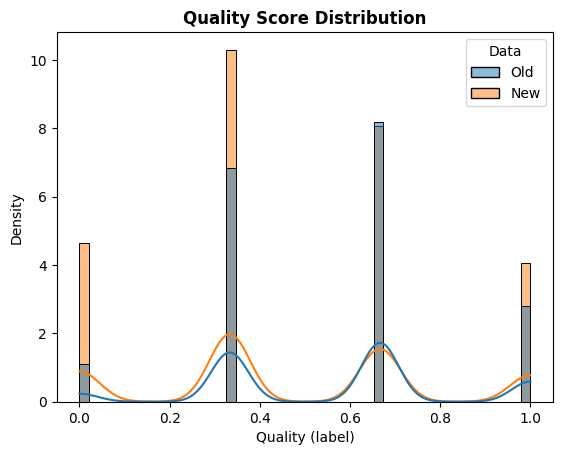

In [7]:
sns.histplot(data=comparison_results, x='Quality', hue='Data', kde=True, stat='density')
plt.title('Quality Score Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Quality (label)')

In [12]:
comparison_results

,Quality,Contamination,FR,Data,eid
0,0.666667,0.000000,0.868433,Old,2bdf206a-820f-402f-920a-9e86cd5388a4
1,0.666667,0.005589,5.001561,Old,2bdf206a-820f-402f-920a-9e86cd5388a4
2,1.000000,0.000000,5.104708,Old,2bdf206a-820f-402f-920a-9e86cd5388a4
3,0.666667,0.024517,1.688521,Old,2bdf206a-820f-402f-920a-9e86cd5388a4
4,0.666667,10.594954,0.081226,Old,2bdf206a-820f-402f-920a-9e86cd5388a4
...,...,...,...,...,...
27214,0.666667,0.000000,0.224128,New,4b7fbad4-f6de-43b4-9b15-c7c7ef44db4b
27215,0.666667,0.241260,0.752771,New,4b7fbad4-f6de-43b4-9b15-c7c7ef44db4b
27216,0.666667,0.736236,0.304707,New,4b7fbad4-f6de-43b4-9b15-c7c7ef44db4b
27217,0.666667,0.000000,0.066415,New,4b7fbad4-f6de-43b4-9b15-c7c7ef44db4b


In [18]:
comparison_results[comparison_results['eid']==eids[1]]['Contamination']

1450       0.000000
1451      15.541061
1452     499.534110
1453       0.372265
1454     205.106097
           ...     
1993     955.158556
1994       0.178385
1995       0.000000
1996       0.000000
1997    2302.401486
Name: Contamination, Length: 548, dtype: float64

/home/blopes/.pyenv/versions/ibl/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


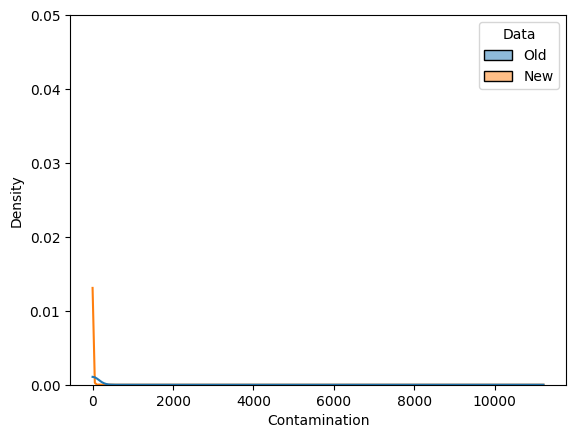

In [21]:
comparison_results_eid = comparison_results[comparison_results['eid']==eids[7]]
sns.histplot(data=comparison_results_eid, x='Contamination', hue='Data', kde=True, stat='density')
plt.ylim(0, 0.05)
plt.show()

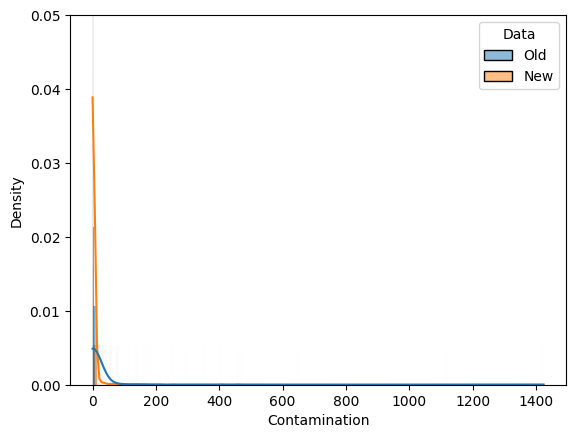

/home/blopes/.pyenv/versions/ibl/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


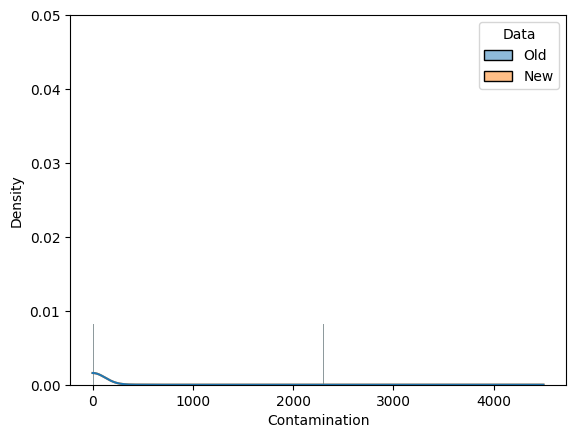

KeyboardInterrupt: 

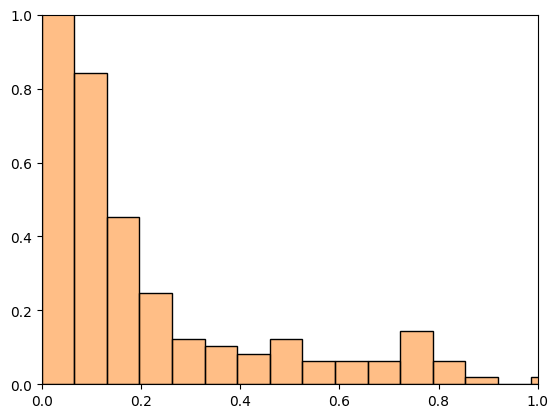

In [16]:
for eid in eids:
    comparison_results_eid = comparison_results[comparison_results['eid']==eid]
    sns.histplot(data=comparison_results_eid, x='Contamination', hue='Data', kde=True, stat='density')
    plt.ylim(0, 0.05)
    plt.show()


In [ ]:

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Quality
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(data=comparison_results, x='Quality', hue='Data', kde=True, ax=ax1, stat='density')
ax1.set_title('Quality Score Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Quality (label)')


# Contamination
ax4 = fig.add_subplot(gs[1, 0])
sns.histplot(data=comparison_results, x='Contamination', hue='Data', kde=True, ax=ax4, stat='density')
ax4.set_title('Contamination Distribution', fontsize=12, fontweight='bold')
ax4.set_xlabel('Contamination')

ax5 = fig.add_subplot(gs[1, 1])
sns.violinplot(data=comparison_results, x='Data', y='Contamination', ax=ax5, palette='Set2')
ax5.set_title('Contamination Distribution (Violin)', fontsize=12, fontweight='bold')

ax6 = fig.add_subplot(gs[1, 2])
sns.boxplot(data=comparison_results, x='Data', y='Contamination', ax=ax6, palette='Set2')
ax6.set_title('Contamination Box Plot', fontsize=12, fontweight='bold')

# Firing rate 
ax7 = fig.add_subplot(gs[2, 0])
sns.histplot(data=comparison_results, x='FR', hue='Data', kde=True, ax=ax7, stat='density')
ax7.set_title('Firing Rate Distribution', fontsize=12, fontweight='bold')
ax7.set_xlabel('Firing Rate (Hz)')

ax8 = fig.add_subplot(gs[2, 1])
sns.violinplot(data=comparison_results, x='Data', y='FR', ax=ax8, palette='Set2')
ax8.set_title('Firing Rate Distribution (Violin)', fontsize=12, fontweight='bold')

ax9 = fig.add_subplot(gs[2, 2])
sns.boxplot(data=comparison_results, x='Data', y='FR', ax=ax9, palette='Set2')
ax9.set_title('Firing Rate Box Plot', fontsize=12, fontweight='bold')

plt.savefig('../results/revision_comparison_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ===== 4. QUALITY vs CONTAMINATION SCATTER =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, revision in enumerate(['Old', 'New']):
    subset = comparison_results[comparison_results['Data'] == revision]
    axes[i].scatter(subset['Quality'], subset['Contamination'], alpha=0.6, s=30)
    axes[i].set_xlabel('Quality (label)')
    axes[i].set_ylabel('Contamination')
    axes[i].set_title(f'{revision} Revision: Quality vs Contamination')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/quality_vs_contamination.png', dpi=150, bbox_inches='tight')
plt.show()

# ===== 5. SESSION-LEVEL SUMMARY =====
session_summary = comparison_results.groupby(['eid', 'Data']).agg({
    'Quality': ['mean', 'std', 'count'],
    'Contamination': 'mean',
    'FR': 'mean'
}).round(3)

print("\nSession-level summary:")
print(session_summary)

# ===== 6. UNIT COUNTS BY SESSION =====
fig, ax = plt.subplots(figsize=(14, 6))
unit_counts = comparison_results.groupby(['eid', 'Data']).size().unstack(fill_value=0)
unit_counts.plot(kind='bar', ax=ax, width=0.7)
ax.set_title('Unit Count Comparison by Session', fontsize=12, fontweight='bold')
ax.set_xlabel('Session')
ax.set_ylabel('Number of Units')
ax.legend(title='Revision', labels=['New', 'Old'])
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../results/unit_counts_by_session.png', dpi=150, bbox_inches='tight')
plt.show()

# ===== 7. PERCENT CHANGE IN KEY METRICS =====
metrics_by_session = comparison_results.groupby(['eid', 'Data']).agg({
    'Quality': 'mean',
    'Contamination': 'mean',
    'FR': 'mean'
}).unstack()

old_quality = metrics_by_session['Quality']['Old']
new_quality = metrics_by_session['Quality']['New']
quality_change = 100 * (new_quality - old_quality) / old_quality

old_cont = metrics_by_session['Contamination']['Old']
new_cont = metrics_by_session['Contamination']['New']
cont_change = 100 * (new_cont - old_cont) / old_cont

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(quality_change)), quality_change.values)
axes[0].set_title('Quality Change: New vs Old (%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Session')
axes[0].set_ylabel('% Change')
axes[0].axhline(y=0, color='k', linestyle='--', linewidth=0.5)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(range(len(cont_change)), cont_change.values)
axes[1].set_title('Contamination Change: New vs Old (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Session')
axes[1].set_ylabel('% Change')
axes[1].axhline(y=0, color='k', linestyle='--', linewidth=0.5)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/metric_changes_by_session.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_2449018/498870318.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=comparison_results, x='Data', y='Quality', ax=ax2, palette='Set2')
/tmp/ipykernel_2449018/498870318.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=comparison_results, x='Data', y='Quality', ax=ax3, palette='Set2')


KeyboardInterrupt: 

: 

: 